<h1><center>Customer Churn Analysis</center></h1>

A bank wants to know which customers are likely to close their accounts (`Exited = 1`). The file is the standard *Churn Modelling* table: credit score, geography, gender, age, tenure, balance, products, card and activity flags, estimated salary, and the exit label.

The notebook runs in four parts.

**Part 1 — Setup and data**

| Section | What it does |
| --- | --- |
| 1 · Setup | Imports |
| 2 · Load the data | Read the CSV and write a local copy for the Streamlit app |

**Part 2 — Visualizations**

| Section | What it does |
| --- | --- |
| 3 · Credit scores | Shape of the credit-score distribution |
| 4 · Salary by gender | Whether pay differs enough to explain churn by itself |
| 5 · Balance vs exit | How balances compare between customers who stayed and who left |

**Part 3 — Preprocessing**

| Section | What it does |
| --- | --- |
| 6 · Features and target | Drop identifiers; keep the ten behavioral fields |
| 7 · Encode gender | Label-encode Female / Male |
| 8 · Encode geography | One-hot encode France / Germany / Spain |
| 9 · Train/test split | 80/20 holdout |
| 10 · Scale | Standardize every column after encoding |

**Part 4 — Artificial neural network**

| Section | What it does |
| --- | --- |
| 11 · Architecture | Two hidden layers of 6 ReLU units, sigmoid output |
| 12 · Train | Adam, binary cross-entropy, 100 epochs |
| 13 · Test-set predictions | 0.5 probability cutoff |
| 14 · Confusion matrix and accuracy | Headline test metrics |
| 15 · One-customer check | Score a single hand-built row |
| 16 · Summary and conclusions | What the fit supports and what it does not |

**Scope.** This is a baseline dense network on a public tabular dataset. There is no validation split, class weighting, or out-of-time test. The Streamlit app trains the same 6-6-1 architecture via `train_model.py`.


# Part 1 — Setup and data

## 1 · Setup

TensorFlow/Keras builds the network. Scikit-learn handles encoding, the train/test split, scaling, and the confusion matrix. Seaborn draws the three EDA charts.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler


## 2 · Load the data

Identifiers (`RowNumber`, `CustomerId`, `Surname`) stay on the frame for EDA and are dropped only when `X` is built. A local `churn_model.csv` is written so `train_model.py` and the dashboard can load the same table without the original OneDrive path.


In [2]:
# Prefer a CSV sitting next to the notebook. Fall back to the original OneDrive
# path so this cell still runs on the machine where the file was first copied.
candidates = [
    Path("Churn_Modelling.csv"),
    Path("churn_model.csv"),
    Path("ChurnAnalysis/Churn_Modelling.csv"),
    Path("ChurnAnalysis/churn_model.csv"),
    Path(
        "/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/"
        "my_portfolio_files/Churn_Modelling.csv"
    ),
]
csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        "Put Churn_Modelling.csv (or churn_model.csv) in the ChurnAnalysis folder."
    )

ds = pd.read_csv(csv_path)
print(f"loaded {csv_path} — {len(ds):,} rows x {ds.shape[1]} columns")
ds.head()


loaded churn_model.csv — 10,000 rows x 14 columns


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Local copy used by train_model.py and app.py.
ds.to_csv("churn_model.csv", index=False)


In [4]:
# Exit rate: about one in five customers left. Accuracy near 80% is therefore
# close to a majority-class baseline and is not, by itself, a strong result.
print(ds["Exited"].value_counts())
print(ds["Exited"].mean())


Exited
0    7963
1    2037
Name: count, dtype: int64
0.2037


# Part 2 — Visualizations

## 3 · Credit scores

A unimodal pile around the mid-600s is typical for this file. Credit score alone does not separate churners; it is one of several weak tabular signals the network will combine.


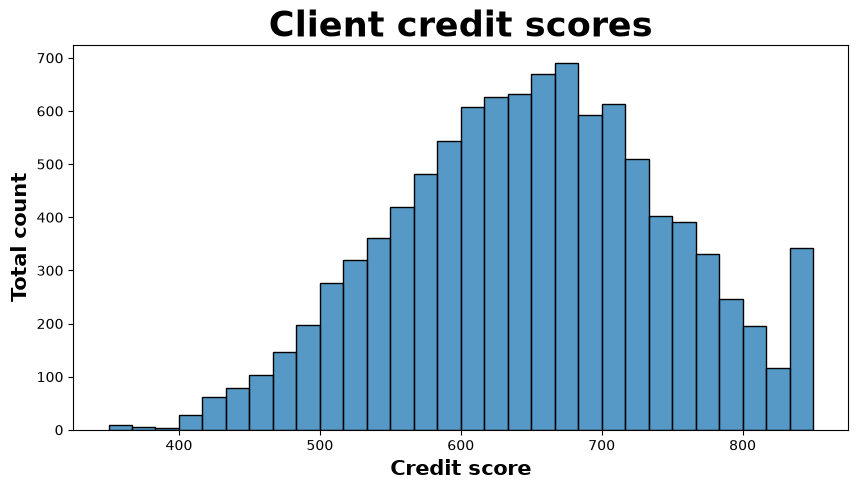

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(data=ds, x="CreditScore", bins=30)
plt.title("Client credit scores", fontsize=25, weight="bold")
plt.xlabel("Credit score", fontsize=15, weight="bold")
plt.ylabel("Total count", fontsize=15, weight="bold")
plt.show()


## 4 · Salary by gender

Estimated salary is a noisy, self-reported-style field in this dataset. The boxplots for men and women largely overlap, so gender differences in pay are not an obvious churn driver on their own. Gender still enters the model because it can interact with geography and products.


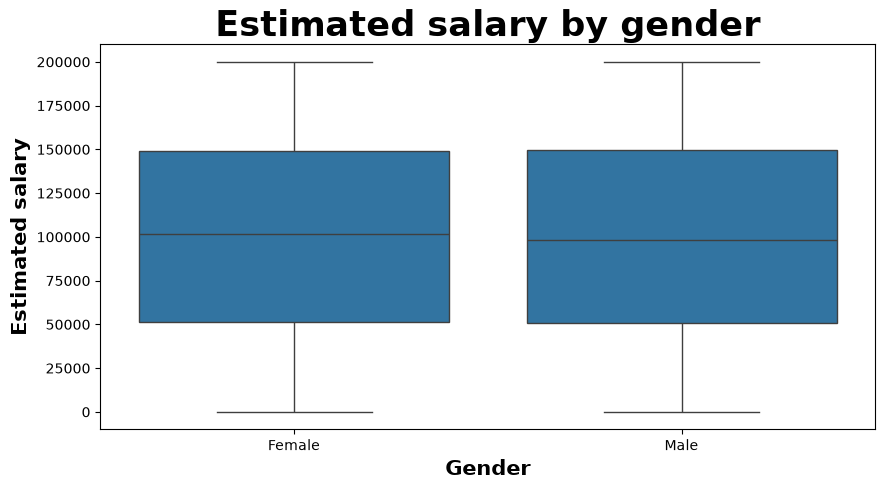

In [6]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=ds, x="Gender", y="EstimatedSalary")
plt.title("Estimated salary by gender", fontsize=25, weight="bold")
plt.xlabel("Gender", fontsize=15, weight="bold")
plt.ylabel("Estimated salary", fontsize=15, weight="bold")
plt.show()


## 5 · Balance vs exit

`Exited = 1` means the customer left. In this table, leavers tend to hold **higher** average balances than those who stay — the opposite of "empty accounts churn." A mean bar chart does not show spread or confounding by country; it is a prompt to keep `Balance` in the model, not a causal claim.


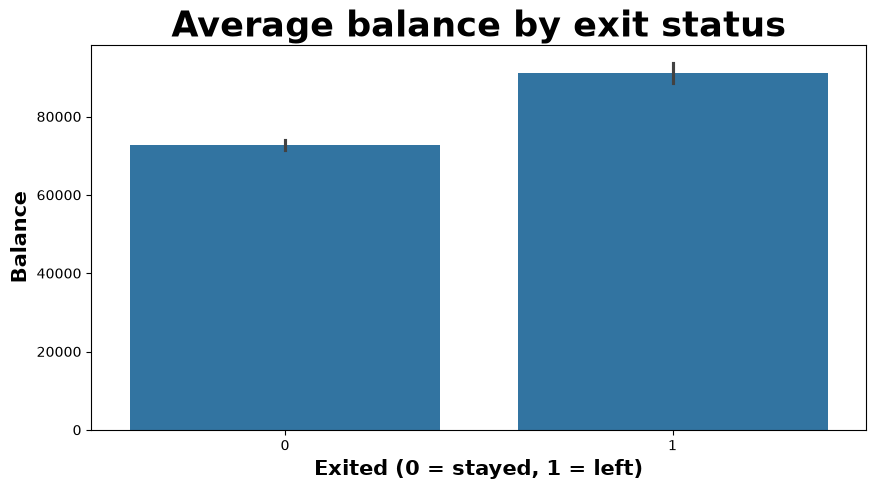

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(data=ds, x="Exited", y="Balance")
plt.title("Average balance by exit status", fontsize=25, weight="bold")
plt.xlabel("Exited (0 = stayed, 1 = left)", fontsize=15, weight="bold")
plt.ylabel("Balance", fontsize=15, weight="bold")
plt.show()


# Part 3 — Preprocessing

## 6 · Features and target

`iloc[:, 3:-1]` drops the first three identifier columns and the last column (`Exited`). What remains, in order, is:

`CreditScore`, `Geography`, `Gender`, `Age`, `Tenure`, `Balance`, `NumOfProducts`, `HasCrCard`, `IsActiveMember`, `EstimatedSalary`.

`.values` turns that into a NumPy array so later cells can encode by **column index** (geography is 1, gender is 2). The Streamlit training path uses named columns instead; the fields are the same.


In [8]:
X = ds.iloc[:, 3:-1].values
y = ds.iloc[:, -1].values


In [9]:
print(X)


[[619 'France' 'Female' ... 1 1 101348.88]
 [608 'Spain' 'Female' ... 0 1 112542.58]
 [502 'France' 'Female' ... 1 0 113931.57]
 ...
 [709 'France' 'Female' ... 0 1 42085.58]
 [772 'Germany' 'Male' ... 1 0 92888.52]
 [792 'France' 'Female' ... 1 0 38190.78]]


In [10]:
print(y)


[1 0 1 ... 1 1 0]


## 7 · Encode gender

`LabelEncoder` maps categories to 0/1 in **alphabetical** order: Female → 0, Male → 1. Fit on the full `X` before the split, which is slightly leaky (the mapping would be the same on train-only for a two-level field). Trees would not need this encoding; a dense net does.


In [11]:
le = LabelEncoder()
X[:, 2] = le.fit_transform(X[:, 2])


In [12]:
print(X)


[[619 'France' 0 ... 1 1 101348.88]
 [608 'Spain' 0 ... 0 1 112542.58]
 [502 'France' 0 ... 1 0 113931.57]
 ...
 [709 'France' 0 ... 0 1 42085.58]
 [772 'Germany' 1 ... 1 0 92888.52]
 [792 'France' 0 ... 1 0 38190.78]]


## 8 · Encode geography

`OneHotEncoder` on column 1 expands France / Germany / Spain into three 0/1 columns, placed **at the front** of `X` (`remainder='passthrough'`). Categories are sorted alphabetically, so a later one-row example uses `[1, 0, 0]` for France.

`drop='first'` is not used, so all three dummies are kept. That is a redundant encoding with an intercept (dummy-variable trap) for linear models; a neural net can still fit, which is why `train_model.py` mirrors this choice.


In [13]:
ct = ColumnTransformer(
    transformers=[("encoder", OneHotEncoder(), [1])],
    remainder="passthrough",
)
X = np.array(ct.fit_transform(X))


In [14]:
print(X)


[[1.0 0.0 0.0 ... 1 1 101348.88]
 [0.0 0.0 1.0 ... 0 1 112542.58]
 [1.0 0.0 0.0 ... 1 0 113931.57]
 ...
 [1.0 0.0 0.0 ... 0 1 42085.58]
 [0.0 1.0 0.0 ... 1 0 92888.52]
 [1.0 0.0 0.0 ... 1 0 38190.78]]


## 9 · Train/test split

20% holdout, `random_state=0` so reruns match. There is **no `stratify=y`**, so the exit rate in test can drift a little from 20%. There is also no validation fold inside the 80% — early stopping is not used in the next part.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)


## 10 · Scale

`StandardScaler` is fit on **train only**, then applied to test. That includes the dummy columns. Scaling is required here: Adam still works better when inputs share a scale, and the original salary / balance magnitudes dwarf 0/1 flags.

Do not fit the scaler on train and test stacked together — that leaks test moments into the transform.


In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Part 4 — Artificial neural network

## 11 · Architecture

A `Sequential` stack: hidden Dense(6, ReLU), hidden Dense(6, ReLU), output Dense(1, sigmoid). The sigmoid is a churn **probability**. Binary cross-entropy matches that output. Adam is the default adaptive optimizer.

Six units is a small hidden width for 12 inputs (3 geography dummies + 9 other fields). That is a capacity choice, not a claim that six is optimal. There is no dropout or regularization beyond Adam's defaults.


In [17]:
ann = tf.keras.models.Sequential()


In [18]:
ann.add(tf.keras.layers.Dense(units=6, activation="relu"))
ann.add(tf.keras.layers.Dense(units=6, activation="relu"))
ann.add(tf.keras.layers.Dense(units=1, activation="sigmoid"))
ann.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


## 12 · Train

`batch_size=32` and `epochs=100` match `train_model.py`. Training accuracy is reported each epoch; **test** accuracy is not, because no `validation_data` is passed. The network can overfit the training fold without this cell showing it. Re-running this cell from a fresh kernel retrains from random initial weights, so the confusion matrix will move a little.


In [19]:
ann.fit(X_train, y_train, batch_size=32, epochs=100)


Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 317us/step - accuracy: 0.7946 - loss: 0.5493
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 263us/step - accuracy: 0.7983 - loss: 0.4705
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 255us/step - accuracy: 0.8094 - loss: 0.4421
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 265us/step - accuracy: 0.8142 - loss: 0.4315
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 259us/step - accuracy: 0.8166 - loss: 0.4252
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 259us/step - accuracy: 0.8194 - loss: 0.4201
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 267us/step - accuracy: 0.8220 - loss: 0.4156
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 262us/step - accuracy: 0.8248 - loss: 0.4111
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 262us/step - accuracy: 0.8251 - loss: 0.4066
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 256us/step - accuracy: 0.8276 - loss: 0.4019
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 256us/step - accuracy: 0.8311 - loss: 0.3973
Epoch 12/100
250/25

## 13 · Test-set predictions

Keras returns a probability in `(0, 1)`. The cutoff **0.5** turns that into a hard label. That cutoff is not tuned for a retention-team budget; raising it increases precision and lowers recall.


In [20]:
y_pred = ann.predict(X_test)
y_pred = y_pred > 0.50
print(np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step
[[0 0]
 [0 1]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


## 14 · Confusion matrix and accuracy

Scikit-learn's matrix is `[[TN, FP], [FN, TP]]`. Accuracy is `(TN+TP) / n`. With ~20% churn, always predicting "stayed" already scores ~80%. Read false negatives (missed leavers) if the business cost of churn is high.


In [21]:
cm = confusion_matrix(y_test, y_pred)
print(f"The confusion matrix result is:\n{cm}")
acc = accuracy_score(y_test, y_pred)
print(f"The accuracy score is:\n{acc}")


The confusion matrix result is:
[[1523   72]
 [ 203  202]]
The accuracy score is:
0.8625


## 15 · One-customer check

The row is already in **model space**: three geography dummies, then the remaining fields in the same order as `X` after the column transformer.

`[1, 0, 0, 600, 1, 40, 3, 60000, 2, 1, 1, 50000]` → France, credit score 600, male, age 40, tenure 3, balance 60,000, two products, has a card, is active, salary 50,000.

It must be scaled with the **fitted** `scaler` before `predict`. The printed boolean is whether predicted P(exit) exceeds 0.5, not the probability itself.


In [22]:
print(
    ann.predict(
        scaler.transform([[1, 0, 0, 600, 1, 40, 3, 60000, 2, 1, 1, 50000]])
    )
    > 0.50
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
[[False]]


## 16 · Summary and conclusions

**What was built.** A small feed-forward network on ten customer attributes (after encoding geography and gender) to classify bank churn. The same architecture is what the Streamlit app serves from `models/ann_model.keras`.

**What the results support**

- Identifiers are not features. Customer ID and surname would only memorize rows.
- Geography needs a non-ordinal encoding. Germany is known in this dataset to churn at a higher rate than France or Spain; one-hot encoding lets the first layer see that as its own channel.
- Scaling is not optional for this net. Balances and salaries would dominate unscaled 0/1 flags.
- Accuracy must be read against the ~20% exit rate. The confusion matrix, not the single accuracy number, shows whether leavers are actually being caught.

**What the results do not support**

- **No validation curve.** 100 epochs on train only can overfit. A proper run would pass `validation_split` or a third fold and consider early stopping.
- **No class weight.** Leavers are the minority. Without weighting or a tuned threshold, the net is pulled toward predicting "stay."
- **The 0.5 cutoff is arbitrary.** A retention team would pick a threshold from a precision-recall curve given a contact budget.
- **One hand-built customer is not a test set.** Section 15 only checks that the preprocessing path runs.
- **This is not causal.** Higher average balances among leavers do not mean "raise balances to reduce churn."

**Extending this.** Stratify the split, report precision / recall / ROC AUC, add `class_weight` or focal loss, and persist the Keras model plus scaler with `train_model.py` rather than scoring rows by raw dummy indices.
